# Insurence_Cost_Predcition

**Note:**
- In this experiment, we will perform several operations on a CSV file using the NumPy, Pandas, Matplotlib, Seaborn, and SKLearn libraries.
- Our primary focus will be on key operations commonly used in these libraries for building Linear Regression models.
- The following operations will be conducted on the CSV file:

   - Importing the necessary libraries.
   - Loading the dataset for the experiment.
   - Understanding the data contained in the file.
   - Performing data cleaning and visualisation operations.
   - Preparing the data for further processing within the Data Science Life Cycle.
   - Conducting Exploratory Data Analysis (EDA) on the processed data.
   - Building predictive models using the EDA-processed data.
   - Performing model evaluations.

**Experment Link** --> https://colab.research.google.com/drive/1pRF6KbXbxQUHp_2Av9QlbCzorl82JB7a?usp=sharing

**Data set Link** --> https://drive.google.com/file/d/1Js0IiFk-ZhjOzpfIIRDkz79KM8TaZCUk/view?usp=sharing

### Step 1: Import the necessary libraries.

In [72]:
# Importing the required libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Step 2: Loading the Dataset into the Environment

In [73]:
# Loading the data_set.
df =  pd.read_csv("/content/insurance (1).csv")

In [74]:
# Understanding the data_set.
df.head()

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.21,0.0,no,29087.54313,17.0,715428.0,4720920.992,0.0,55784970.05,southeast,1121.8739
1,18.0,male,30.14,0.0,no,39053.67437,7.0,699157.0,4329831.676,0.0,13700885.19,southeast,1131.5066
2,18.0,male,33.33,0.0,no,39023.62759,19.0,702341.0,6884860.774,0.0,73523107.27,southeast,1135.9407
3,18.0,male,33.66,0.0,no,28185.39332,11.0,700250.0,4274773.550,0.0,75819679.60,southeast,1136.3994
4,18.0,male,34.10,0.0,no,14697.85941,16.0,711584.0,3787293.921,0.0,23012320.01,southeast,1137.0110


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

In [76]:
df.shape

(1338, 13)

- Observing the data set for how many types of data are contained in the CSV_file.
- By this, we understand the dataset's composition and the different data types present in the file.

### Step 3: Data Cleaning Operations Performed on the Dataset.

In [77]:
# checking for null values.
df.isnull().sum()

,0
age,9
sex,0
bmi,3
children,5
smoker,0
Claim_Amount,14
past_consultations,6
num_of_steps,3
Hospital_expenditure,4
NUmber_of_past_hospitalizations,2


In [78]:
df.isnull().sum().sum()

np.int64(52)

In [79]:
# We are dropping the null values from the dataset.
df.dropna(inplace=True)

In [80]:
# checking for duplicate values.
df.duplicated().sum()

np.int64(0)

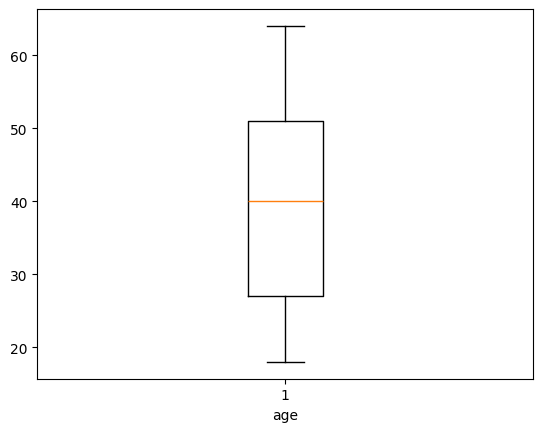

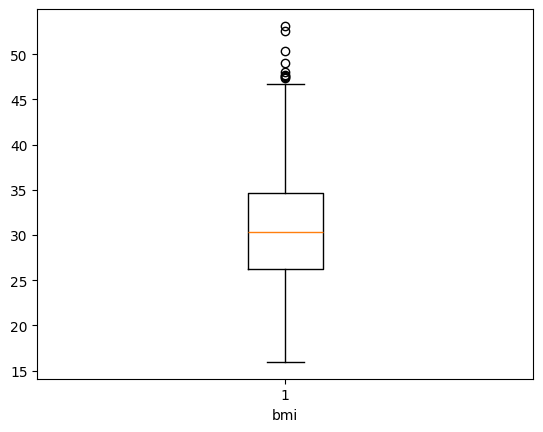

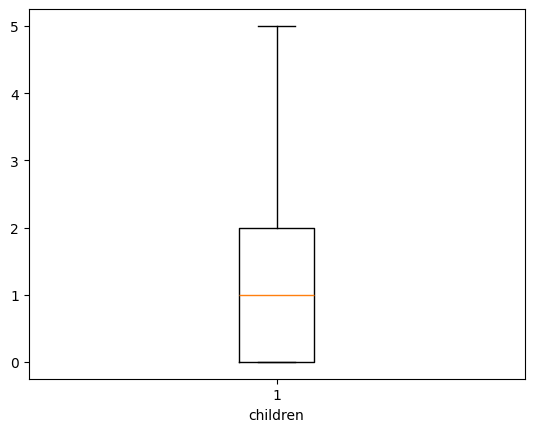

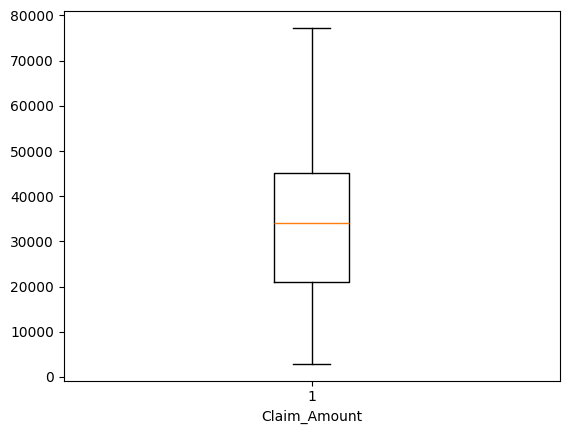

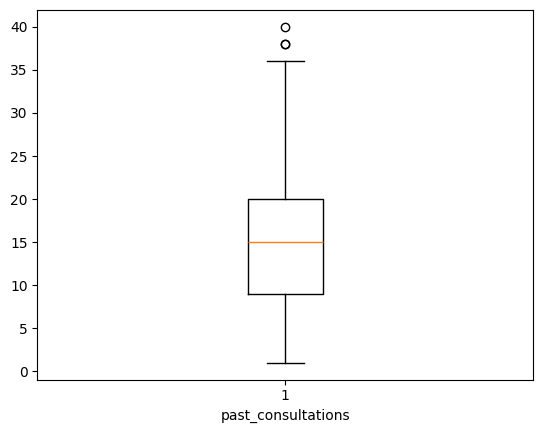

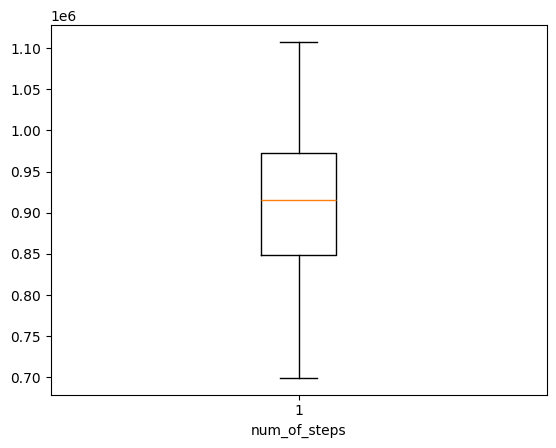

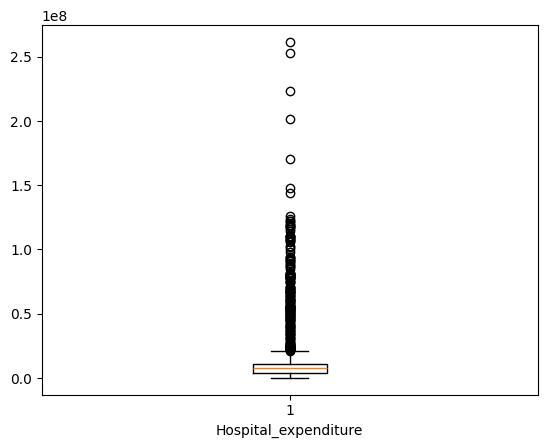

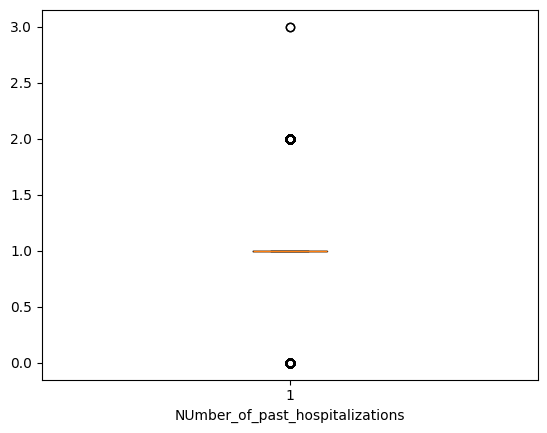

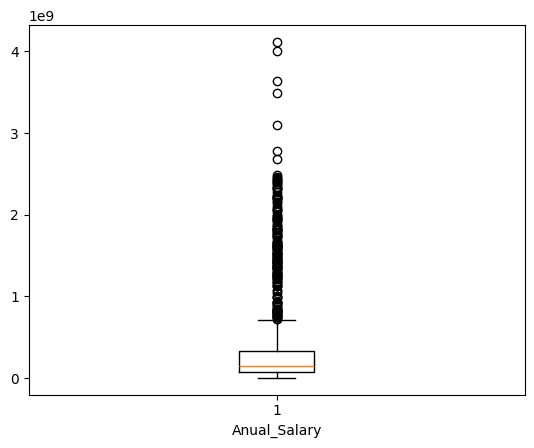

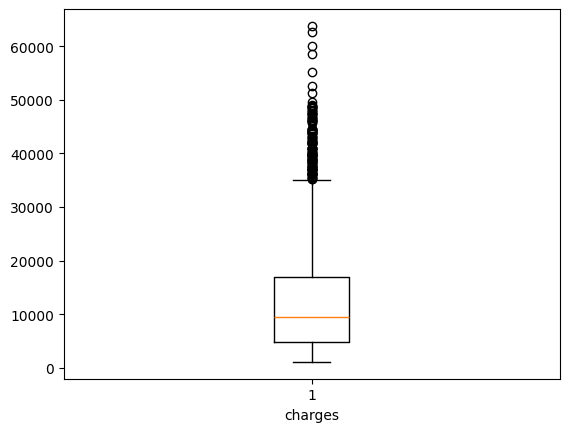

In [81]:
# Checking for outliers in the dataset.
for i in df.columns:
  if df[i].dtypes!='object':
    plt.boxplot(df[i])
    plt.xlabel(i)
    plt.show()

In [82]:
df.shape

(1287, 13)

### Step 4: Removing Outliers (excluding 'charges' and categorical columns)

In [83]:
for i in df.columns:
  if df[i].dtypes!='object' and i!='charges':
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[i] >= lower_bound) & (df[i] <= upper_bound)]

print(f"DataFrame shape after this specific outlier removal: {df.shape}")

DataFrame shape after this specific outlier removal: (851, 13)


### Step 5: Checking for Variance Inflation Factor (VIF) to Identify and Eliminate Multicollinearity

- In this step, we will examine the dataset for the **Variance Inflation Factor (VIF)** to identify and address multicollinearity issues.
- Our goal is to maintain VIF scores below 5.
- To accomplish this, we will remove any columns that have high VIF scores from the dataset.

In [85]:
# Importing the VIF from statsmodeks libaries.
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [86]:
col_list=[]
for i in df.columns:
  if((df[i].dtypes!='object') & (i !='charges')):
    col_list.append(i)


In [87]:
x = df[col_list]
vif_data = pd.DataFrame()
vif_data["feature"] = x.columns
vif_data["VIF"] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]
print(vif_data)

                           feature          VIF
0                              age     2.244063
1                              bmi     1.050993
2                         children     1.077404
3                     Claim_Amount     1.040690
4               past_consultations     1.080557
5                     num_of_steps     5.999974
6             Hospital_expenditure     1.182321
7  NUmber_of_past_hospitalizations  1405.296038
8                     Anual_Salary     4.006099


In [88]:
df = df.drop('NUmber_of_past_hospitalizations', axis=1)

In [89]:
col_list=[]
for i in df.columns:
  if((df[i].dtypes!='object') & (i !='charges')):
    col_list.append(i)

x = df[col_list]
vif_data = pd.DataFrame()
vif_data["feature"] = x.columns
vif_data["VIF"] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]
print(vif_data)

                feature        VIF
0                   age  16.334839
1                   bmi  26.966942
2              children   2.055611
3          Claim_Amount   5.813854
4    past_consultations   6.417597
5          num_of_steps  58.693809
6  Hospital_expenditure   5.524176
7          Anual_Salary   6.183456


In [90]:
df = df.drop('num_of_steps', axis=1)

In [91]:
col_list=[]
for i in df.columns:
  if((df[i].dtypes!='object') & (i !='charges')):
    col_list.append(i)

x = df[col_list]
vif_data = pd.DataFrame()
vif_data["feature"] = x.columns
vif_data["VIF"] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]
print(vif_data)

                feature        VIF
0                   age  13.463550
1                   bmi  14.548677
2              children   1.945699
3          Claim_Amount   5.267436
4    past_consultations   5.911489
5  Hospital_expenditure   5.218410
6          Anual_Salary   5.990854


In [92]:
df = df.drop('bmi', axis=1)

In [93]:
col_list=[]
for i in df.columns:
  if((df[i].dtypes!='object') & (i !='charges')):
    col_list.append(i)

x = df[col_list]
vif_data = pd.DataFrame()
vif_data["feature"] = x.columns
vif_data["VIF"] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]
print(vif_data)

                feature       VIF
0                   age  8.739225
1              children  1.827241
2          Claim_Amount  4.846444
3    past_consultations  5.589741
4  Hospital_expenditure  4.889264
5          Anual_Salary  5.841066


In [94]:
df = df.drop('age', axis=1)

In [95]:
col_list=[]
for i in df.columns:
  if((df[i].dtypes!='object') & (i !='charges')):
    col_list.append(i)

x = df[col_list]
vif_data = pd.DataFrame()
vif_data["feature"] = x.columns
vif_data["VIF"] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]
print(vif_data)

                feature       VIF
0              children  1.816913
1          Claim_Amount  4.264550
2    past_consultations  4.927842
3  Hospital_expenditure  4.672553
4          Anual_Salary  5.107190


- After removing several columns, we arrive at this type of dataframe.

### Step 6: Applying Label Encoding to the data.

In [107]:
# Importing the LabelEncoder from the scikit-learn library.
from sklearn.preprocessing import LabelEncoder

In [108]:
le = LabelEncoder()

In [109]:
for i in x.columns:
  if df[i].dtypes=='object':
    df[i] = le.fit_transform(x[i])

- Now, all columns with the object data type have been converted into numeric data type columns.

### Step 7: Divide the dataset into features (x) and target variable (y) for training the model.

In [110]:
# Splitting the dataset.
x = df.drop('charges', axis=1)
y=df['charges']

In [111]:
x.head()

,sex,children,smoker,Claim_Amount,past_consultations,Hospital_expenditure,Anual_Salary,region
151,1,0.0,0,39148.95495,10.0,8.614147e+06,54526009.33,1
152,0,0.0,0,41547.52536,13.0,2.491594e+05,16718473.13,1
153,1,0.0,0,39660.60193,12.0,3.043323e+06,48526941.68,1
154,1,2.0,0,16032.87148,7.0,1.599069e+06,24412621.85,2
155,0,1.0,0,31090.98977,21.0,3.015365e+06,58535788.80,3


In [112]:
x.shape

(851, 8)

### Step 8: We are splitting the X and Y data into training and testing sets.

In [113]:
# Importing train_test_split from the sklearn library.
from sklearn.model_selection import train_test_split

In [114]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=5)

### Step 9: Building a ML Model Using Linear Regression.

In [115]:
# Importing the model from the sklearn library.
from sklearn.linear_model import LinearRegression

In [116]:
lr = LinearRegression()

In [117]:
lr.fit(x_train, y_train)

LinearRegression()

In [118]:
y_pred = lr.predict(x_test)

In [119]:
predicted_values = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

In [120]:
predicted_values.head()

,Actual,Predicted
332,4719.52405,6242.060282
402,5488.26200,6380.625344
314,4518.82625,6192.329305
992,16069.08475,15414.424861
455,6360.99360,5357.523764


### Step 10: Model Evaluation.

In [124]:
# Importing the evaluation metrics from the sklearn library.
from sklearn.metrics import r2_score

In [125]:
r2_score(y_test, y_pred)*100

83.66953462506409

- After building the ML model, we evaluated it and achieved " 83 % accuracy ".

### Step 11: Visual Representation of Accuracy and the Best Fit Line.

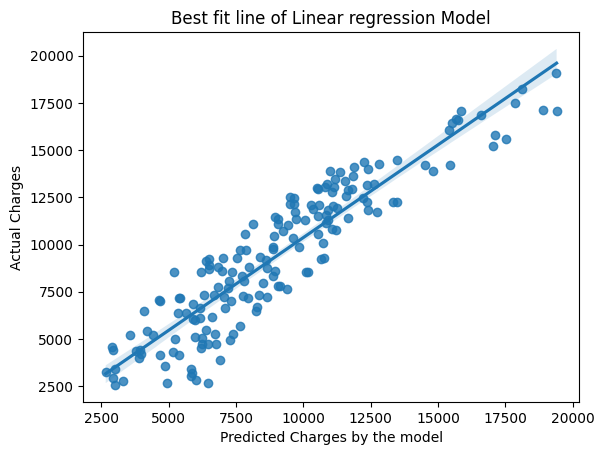

In [123]:
sns.regplot(x=y_pred,y=y_test)
plt.xlabel('Predicted Charges by the model')
plt.ylabel('Actual Charges')
plt.title('Best fit line of Linear regression Model')
plt.show()